In [1]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.circuit.library import RealAmplitudes, ZZFeatureMap
from qiskit_algorithms.optimizers import COBYLA, L_BFGS_B
from qiskit_algorithms.utils import algorithm_globals

from qiskit_machine_learning.algorithms.classifiers import NeuralNetworkClassifier, VQC
from qiskit_machine_learning.algorithms.regressors import NeuralNetworkRegressor, VQR
from qiskit_machine_learning.neural_networks import SamplerQNN, EstimatorQNN
from qiskit_machine_learning.circuit.library import QNNCircuit

algorithm_globals.random_seed = 42

20 smaples for 2 inputs = 
 [[-0.94684447 -0.90108173]
 [ 0.2031169  -0.02761585]
 [-0.47963069 -0.16268783]
 [ 0.51582064  0.65322297]
 [ 0.12244614 -0.22926104]
 [-0.45860648  0.04383694]
 [-0.37050076  0.12819027]
 [ 0.35330477 -0.86784158]
 [-0.99786507 -0.57544572]
 [ 0.789023    0.29258153]
 [-0.6560793   0.78052792]
 [-0.06008812 -0.04781649]
 [ 0.87108389 -0.88102662]
 [-0.56964345  0.17154265]
 [-0.60902698  0.35905402]
 [-0.57181542 -0.80168606]
 [-0.58602968 -0.15453193]
 [-0.6477234  -0.73061595]
 [ 0.72056377 -0.35920559]
 [-0.27848263 -0.88945918]]

 class  label = [0 1 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 1 0]

 class  label when 0 map as -1 = [-1  1 -1  1 -1 -1 -1 -1 -1  1  1 -1 -1 -1 -1 -1 -1 -1  1 -1]
After one hot encoding :=
 [[0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0]]
After ma

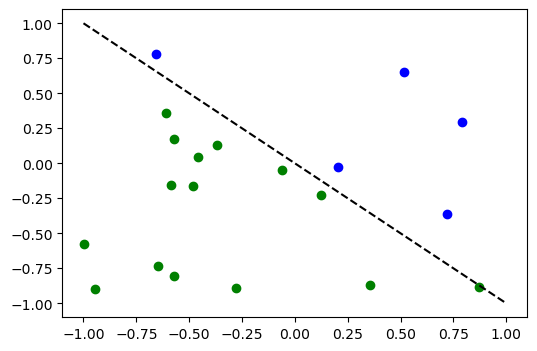

In [52]:
num_inputs = 2
num_samples = 20
X = 2 * algorithm_globals.random.random([num_samples, num_inputs]) - 1
print("20 smaples for 2 inputs = \n",X)
y01 = 1 * (np.sum(X, axis=1) >= 0)  # in { 0,  1}
print("\n class  label =",y01)
y = 2 * y01 - 1  # in {-1, +1}
print("\n class  label when 0 map as -1 =",y)

y_one_hot = np.zeros((num_samples, 2))
print("After one hot encoding :=\n",y_one_hot.tolist())

for i in range(num_samples):
    y_one_hot[i, y01[i]] = 1
    #print("\n",y_one_hot[i])
print("After mapping to one =\n",y_one_hot.tolist())

for x, y_target in zip(X, y):
    if y_target == 1:
        print(x[0], x[1],"\n")
        plt.plot(x[0], x[1], "bo")
    else:
        plt.plot(x[0], x[1], "go")
        print(x[0], x[1])
plt.plot([-1, 1], [1, -1], "--", color="black")
plt.show()

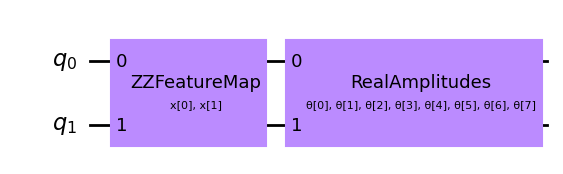

In [24]:
# construct QNN with the QNNCircuit's default ZZFeatureMap feature map and RealAmplitudes ansatz.
qc = QNNCircuit(num_qubits=2)
qc.draw(output="mpl")

In [25]:
estimator_qnn = EstimatorQNN(circuit=qc)
# QNN maps inputs to [-1, +1]
estimator_qnn.forward(X[0, :], algorithm_globals.random.random(estimator_qnn.num_weights))


array([[0.10769409]])

In [26]:
# callback function that draws a live plot when the .fit() method is called
def callback_graph(weights, obj_func_eval):
    clear_output(wait=True)
    objective_func_vals.append(obj_func_eval)
    plt.title("Objective function value against iteration")
    plt.xlabel("Iteration")
    plt.ylabel("Objective function value")
    plt.plot(range(len(objective_func_vals)), objective_func_vals)
    plt.show()

In [53]:
# construct neural network classifier
estimator_classifier = NeuralNetworkClassifier(
    estimator_qnn, optimizer=COBYLA(maxiter=100), callback=callback_graph
)
print(estimator_classifier)

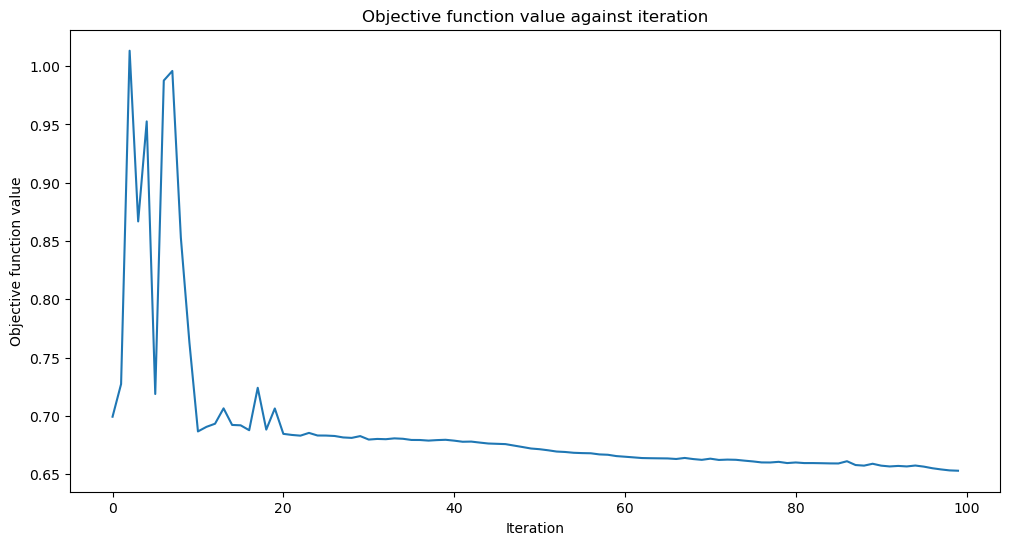

0.8

In [55]:
# create empty array for callback to store evaluations of the objective function
objective_func_vals = []
plt.rcParams["figure.figsize"] = (12, 6)

# fit classifier to data
estimator_classifier.fit(X, y)

# return to default figsize
plt.rcParams["figure.figsize"] = (6, 4)

# score classifier
estimator_classifier.score(X, y)

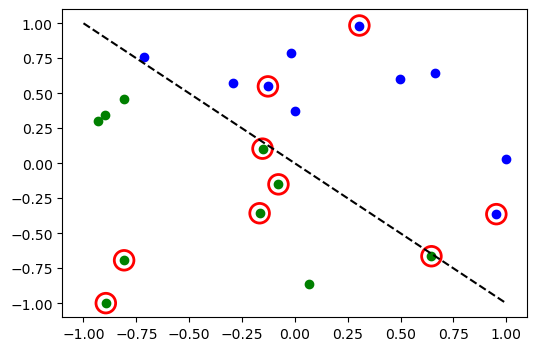

In [49]:
# evaluate data points
y_predict = estimator_classifier.predict(X)
# plot results
# red == wrongly classified
for x, y_target, y_p in zip(X, y, y_predict):
    if y_target == 1:
        plt.plot(x[0], x[1], "bo")
    else:
        plt.plot(x[0], x[1], "go")
    if y_target != y_p:
        plt.scatter(x[0], x[1], s=200, facecolors="none", edgecolors="r", linewidths=2)
plt.plot([-1, 1], [1, -1], "--", color="black")
plt.show()